# All Bark and No Byte?

**Does a country's tone about digital transformation relate to real improvements in its internet infrastructure?**

| | |
|---|---|
| **SDG** | SDG 9 - Industry, innovation and infrastructure (target 9.c: universal, affordable access to ICT) |
| **GA theme** | *Restoring trust, managing transformation* |
| **Connection** | Digital transformation is the "transformation" half of the theme and the core of SDG 9.c. The "trust" half asks the obvious follow-up: do the countries that *talk* about digital progress actually *deliver* it? Perceived corruption links the two, because it erodes trust in institutions and undermines infrastructure investment. |

**Q1 (exploratory).** How does the sentiment of digital-transformation language in General Debate speeches relate to a country's internet access rates and mobile subscriptions over time?

**Q2 (predictive).** To what extent can that sentiment predict the change in a country's internet access rate *in the following year*, and does perceived corruption moderate the relationship?

### How the question is measured

| Concept | Operationalisation |
|---|---|
| **Digital-transformation language** | Every sentence that uses vocabulary from the `digital_infrastructure` *or* `internet_and_access` lexicons (broadband, connectivity, internet, ICT, digital divide, social media, artificial intelligence, ...). The union of the two SDG 9 digital facets in `lexicons.py`. |
| **Sentiment** | Mean VADER compound score (-1 to +1) of those sentences, per speech. Same VADER model the pipeline uses. |
| **Alternative framings** | *Net tone* (share positive minus share negative), *promise framing* (share of those sentences that also use opportunity vocabulary such as "opportunity", "empower", "leapfrog"), *salience* (share of the speech's sentences). |
| **Internet access** | World Bank: individuals using the Internet (% of population). Mobile: subscriptions per 100 people. Fixed broadband per 100 as a robustness outcome. |
| **Perceived corruption** | World Happiness Report "Perceptions of corruption" (0-1, **higher = more corrupt**), 2005 onward. |

Every speech is one country-year, so everything joins on `(country_code, year)`.


## 0. Setup

In [1]:
import hashlib
import json
import logging
import warnings

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

from un_general_debate_analysis.external import load_all
from un_general_debate_analysis.lexicons import FRAME_LEXICONS, TECH_FACETS
from un_general_debate_analysis.preprocessing import (
    OUT_DIR,
    ensure_nltk_resources,
    lexicon_matcher,
    normalise_tokens,
    sentiment_analyser,
)

warnings.filterwarnings("ignore", category=FutureWarning)
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)  # no "semibold" font in some setups
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

# one palette for the whole notebook (same as the other SDG 9 notebooks)
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4",
          "#008300", "#4a3aa7", "#e34948"]
BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED = SERIES
INK, INK_SOFT, GRID = "#0b0b0b", "#52514e", "#dddcd7"
SEQ_BLUE = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110, "figure.facecolor": "white",
    "axes.facecolor": "white", "axes.edgecolor": GRID, "axes.labelcolor": INK_SOFT,
    "axes.titlesize": 12, "axes.titleweight": "semibold", "axes.titlecolor": INK,
    "axes.titlelocation": "left", "axes.titlepad": 10, "axes.labelsize": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "grid.alpha": 0.9,
    "xtick.color": INK_SOFT, "ytick.color": INK_SOFT,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.frameon": False, "legend.fontsize": 9,
    "lines.linewidth": 2.0, "lines.markersize": 5, "font.size": 10,
})


def finish(ax, title=None, subtitle=None, xlabel=None, ylabel=None, legend=True):
    """Titles, labels and a recessive grid, applied the same way everywhere."""
    if title:
        ax.set_title(title, pad=16)
    if subtitle:
        ax.text(0, 1.01, subtitle, transform=ax.transAxes, fontsize=9,
                color=INK_SOFT, va="bottom")
    ax.set_xlabel(xlabel or "")
    ax.set_ylabel(ylabel or "")
    ax.set_axisbelow(True)
    ax.yaxis.grid(False)
    if legend and ax.get_legend_handles_labels()[0]:
        ax.legend(loc="best")
    return ax


In [2]:
class Fit:
    """Result of :func:`fit`: coefficients, cluster-robust covariance, fit stats."""

    def __init__(self, coef, cov, n, n_countries, r2):
        self.coef, self.cov, self.n, self.n_countries, self.r2 = coef, cov, n, n_countries, r2
        self.se = pd.Series(np.sqrt(np.diag(cov)), index=cov.index)
        self.t = coef / self.se

    def ci(self, name, z=1.96):
        return self.coef[name] - z * self.se[name], self.coef[name] + z * self.se[name]


def _design(d, x, controls, year_fe, country_fe):
    """Regressor matrix: x + controls (+ year dummies), demeaned by country if country_fe."""
    X = d[[*x, *controls]].astype(float)
    if year_fe:
        X = pd.concat([X, pd.get_dummies(d["year"], prefix="yr", drop_first=True).astype(float)], axis=1)
    if country_fe:
        X = X - X.groupby(d["country_code"]).transform("mean")
    else:
        X.insert(0, "const", 1.0)
    return X


def fit(df, y, x, controls=(), year_fe=True, country_fe=False):
    """OLS with country-clustered standard errors (numpy only; statsmodels is not a dependency).

    ``year_fe`` adds year dummies, ``country_fe`` adds country fixed effects through the
    within transformation. Rows with a missing value in any used column are dropped.
    """
    d = df.dropna(subset=[y, *x, *controls]).copy()
    X = _design(d, x, controls, year_fe, country_fe)
    yv = d[y].astype(float)
    if country_fe:
        yv = yv - yv.groupby(d["country_code"]).transform("mean")
    Xv, yv = X.to_numpy(), yv.to_numpy()
    b, *_ = np.linalg.lstsq(Xv, yv, rcond=None)
    e = yv - Xv @ b
    bread = np.linalg.pinv(Xv.T @ Xv)
    meat = np.zeros((Xv.shape[1],) * 2)
    codes = d["country_code"].to_numpy()
    for c in np.unique(codes):
        s = Xv[codes == c].T @ e[codes == c]
        meat += np.outer(s, s)
    g, (n, k) = len(np.unique(codes)), Xv.shape
    cov = bread @ meat @ bread * (g / (g - 1)) * ((n - 1) / (n - k))
    names = [*x, *controls]
    cov = pd.DataFrame(cov, index=X.columns, columns=X.columns).loc[names, names]
    coef = pd.Series(b, index=X.columns).loc[names]
    return Fit(coef, cov, n, g, 1 - (e @ e) / ((yv - yv.mean()) @ (yv - yv.mean())))


def zscore(s):
    return (s - s.mean()) / s.std()


## 1. Data

`speeches_features.csv` already holds VADER sentiment per lexicon, but separately for each of the two digital facets. Our measure is their **union**, so we re-score the sentences ourselves, reusing the pipeline's tokeniser, lemmatiser, phrase matcher and VADER instance so the sentence selection is exactly what the pipeline would have chosen.


In [3]:
features = pd.read_csv(OUT_DIR / "speeches_features.csv")
external = load_all(verbose=False)
assert not external.duplicated(["country_code", "year"]).any()
assert not features.duplicated(["country_code", "year"]).any()

print(f"speeches: {len(features):,} ({features['year'].min()}-{features['year'].max()}), "
      f"{features['country_code'].nunique()} countries")
print(f"external: {len(external):,} country-years, {external['year'].min()}-{external['year'].max()}")
features[["country_code", "year", "digital_infrastructure_sentences", "internet_and_access_sentences",
          "digital_infrastructure_sentiment", "internet_and_access_sentiment"]].query("year == 2020").head(3)


speeches: 11,141 (1946-2025), 200 countries
external: 17,130 country-years, 1960-2025


,country_code,year,digital_infrastructure_sentences,internet_and_access_sentences,digital_infrastructure_sentiment,internet_and_access_sentiment
9987,AFG,2020,0,0,0.000,0.000
9988,AGO,2020,0,0,0.000,0.000
9989,ALB,2020,0,0,0.000,0.000


The result is cached in `data/processed/` and keyed on the vocabulary, so it is only recomputed when `lexicons.py` changes (about 15 seconds).

**The first thing to notice is how little text there is.** Only about one speech in six ever contains a digital-transformation sentence, and the *median* such speech has exactly one. A speech's "sentiment" is therefore usually the VADER score of a single sentence. That is noisy, and it shapes every design choice below: sentiment is undefined when a country says nothing, so most analyses use the speeches that say something, and we test a few denser alternatives (trailing means, salience, all-speech models).


In [4]:
from nltk import sent_tokenize, word_tokenize

DIGITAL_LEXICONS = {"digital_infrastructure", "internet_and_access"}
PROMISE_LEXICON = "frame_promise"


def score_digital_sentences(text_clean: str, drop: frozenset = frozenset()) -> tuple[int, float, int, int, int]:
    """(n sentences, sum of VADER compound, n positive, n negative, n promise-framed)
    over the sentences that mention either digital lexicon.

    Tokenising, lemmatising and phrase matching go through the pipeline's own
    ``lexicon_matcher`` and VADER instance, so a sentence is "digital" exactly when
    the pipeline would have flagged it for ``digital_infrastructure`` or
    ``internet_and_access``. Tokens in ``drop`` are ignored (used for the strict vocabulary).
    """
    merger, term_to_lexicons = lexicon_matcher()
    sia = sentiment_analyser()
    n = pos = neg = promise = 0
    total = 0.0
    for sentence in sent_tokenize(text_clean):
        hit = set()
        for token in merger.tokenize(normalise_tokens(word_tokenize(sentence))):
            if token not in drop:
                hit.update(term_to_lexicons.get(token, ()))
        if not hit & DIGITAL_LEXICONS:
            continue
        compound = sia.polarity_scores(sentence)["compound"]
        n, total = n + 1, total + compound
        pos, neg = pos + (compound >= 0.05), neg + (compound <= -0.05)
        promise += PROMISE_LEXICON in hit
    return n, total, pos, neg, promise


def digital_scores(drop: frozenset = frozenset()) -> pd.DataFrame:
    """Per-speech digital-sentence scores, cached under data/processed/.

    The cache is keyed on the vocabulary (and on ``drop``), so editing lexicons.py
    invalidates it automatically.
    """
    key = hashlib.md5(json.dumps(
        [TECH_FACETS["digital_infrastructure"], TECH_FACETS["internet_and_access"],
         FRAME_LEXICONS[PROMISE_LEXICON], sorted(drop)]).encode()).hexdigest()[:8]
    cache = OUT_DIR / f"digital_transformation_sentences_{key}.csv"
    if cache.exists():
        return pd.read_csv(cache)
    ensure_nltk_resources()
    # Only speeches the pipeline saw a digital term in can contain a digital sentence.
    flagged = features.loc[(features["digital_infrastructure"] > 0) | (features["internet_and_access"] > 0),
                           ["country_code", "year"]]
    texts = pd.read_csv(OUT_DIR / "speeches_text.csv.gz", usecols=["country_code", "year", "text_clean"])
    texts = texts.merge(flagged, on=["country_code", "year"])
    scored = [score_digital_sentences(t, drop) for t in texts["text_clean"].fillna("")]
    out = pd.concat([texts[["country_code", "year"]].reset_index(drop=True),
                     pd.DataFrame(scored, columns=["dig_n", "dig_sum", "dig_pos", "dig_neg", "dig_promise"])],
                    axis=1)
    out = out[out["dig_n"] > 0]
    out.to_csv(cache, index=False)
    return out


digital = digital_scores()
print(f"{len(digital):,} speeches contain at least one digital-transformation sentence")
print(digital["dig_n"].describe().round(2).to_string())


1,817 speeches contain at least one digital-transformation sentence
count   1,817.000
mean        1.610
std         1.310
min         1.000
25%         1.000
50%         1.000
75%         2.000
max        17.000


In [5]:
# Sanity check: the union can never have fewer sentences than its larger facet.
chk = digital.merge(features, on=["country_code", "year"])
floor = chk[["digital_infrastructure_sentences", "internet_and_access_sentences"]].max(axis=1)
ceil = chk["digital_infrastructure_sentences"] + chk["internet_and_access_sentences"]
print(f"union >= larger facet in {(chk['dig_n'] >= floor).mean():.1%} of speeches, "
      f"<= sum of facets in {(chk['dig_n'] <= ceil).mean():.1%}")


union >= larger facet in 100.0% of speeches, <= sum of facets in 100.0%


### The panel

Outcomes are aligned to the speech year `t`. A speech is delivered in September, so **`gain_next` (`t` to `t+1`) is the first full year after the speech**; `gain_prev` (`t-1` to `t`) and `gain_next2` are used later as placebo and lag checks. Outcomes come from the calendar panel, not from neighbouring speech rows, so a country that skips a year does not lose its valid pairs.

The coverage table shows what limits each analysis: connectivity is available for nearly every speech up to 2024, but corruption only from 2005 and 2025 has no connectivity data yet.


In [6]:
speech = features[["country_code", "country", "year", "region_name", "n_sentences"]].merge(
    digital, on=["country_code", "year"], how="left")
speech[["dig_n", "dig_sum", "dig_pos", "dig_neg", "dig_promise"]] = (
    speech[["dig_n", "dig_sum", "dig_pos", "dig_neg", "dig_promise"]].fillna(0))

speech["mention"] = (speech["dig_n"] > 0).astype(int)
speech["salience"] = speech["dig_n"] / speech["n_sentences"]           # share of the speech's sentences
has = speech["dig_n"].where(speech["dig_n"] > 0)                       # NaN when nothing was said
speech["sentiment"] = speech["dig_sum"] / has                          # mean VADER compound, -1..+1
speech["net_tone"] = (speech["dig_pos"] - speech["dig_neg"]) / has     # positive minus negative share
speech["promise_share"] = speech["dig_promise"] / has                  # share of sentences framed as opportunity

# 5-year trailing mean of a country's sentiment (this year and the four before it,
# whichever of them said something) - a denser, backward-looking version of the signal.
wide = (speech.pivot(index="year", columns="country_code", values="sentiment")
        .reindex(range(features["year"].min(), features["year"].max() + 1)))
trail = wide.rolling(5, min_periods=1).mean().stack().rename("sentiment_5y").reset_index()
speech = speech.merge(trail, on=["country_code", "year"], how="left")

panel = speech.merge(external, on=["country_code", "year"], how="left")
panel["log_gdp"] = np.log(panel["gdp_per_capita_ppp"])
panel["internet_sq"] = panel["internet_users_pct"] ** 2 / 100          # S-curve: growth slows near saturation


def shifted(col, k, name):
    """``col`` measured k calendar years after the speech year, aligned to the speech year."""
    s = external[["country_code", "year", col]].copy()
    s["year"] -= k
    return s.rename(columns={col: name})


for k, name in [(-1, "internet_tm1"), (1, "internet_tp1"), (2, "internet_tp2")]:
    panel = panel.merge(shifted("internet_users_pct", k, name), on=["country_code", "year"], how="left")

# Gains in percentage points of the population online. The speech is given in
# September of year t, so "gain_next" is the first full year after the speech.
panel["gain_prev"] = panel["internet_users_pct"] - panel["internet_tm1"]   # t-1 -> t
panel["gain_next"] = panel["internet_tp1"] - panel["internet_users_pct"]   # t   -> t+1
panel["gain_next2"] = panel["internet_tp2"] - panel["internet_tp1"]        # t+1 -> t+2

modern = panel[(panel["year"] >= 2000)].copy()
coverage = modern.assign(period=lambda f: (f["year"] // 5) * 5).groupby("period").agg(
    speeches=("country_code", "size"),
    say_something_digital=("mention", "sum"),
    internet=("internet_users_pct", "count"),
    mobile=("mobile_per_100", "count"),
    corruption=("perceived_corruption", "count"))
print("how much of the corpus each source covers (speeches per 5-year period)\n")
print(coverage.to_string())


how much of the corpus each source covers (speeches per 5-year period)

        speeches  say_something_digital  internet  mobile  corruption
period                                                               
2000         936                    174       905     925           0
2005         954                    121       923     933         411
2010         965                    199       931     948         632
2015         974                    270       921     948         650
2020         964                    410       886     878         476
2025         190                     92        10       0           0


## 2. Q1 - Exploratory: does the tone of digital talk track connectivity?

### 2.1 Over time: the talk grows, the tone does not

Bark and byte are plotted on the same 5-year axis (2025 is folded into the last period because it has no connectivity data yet).


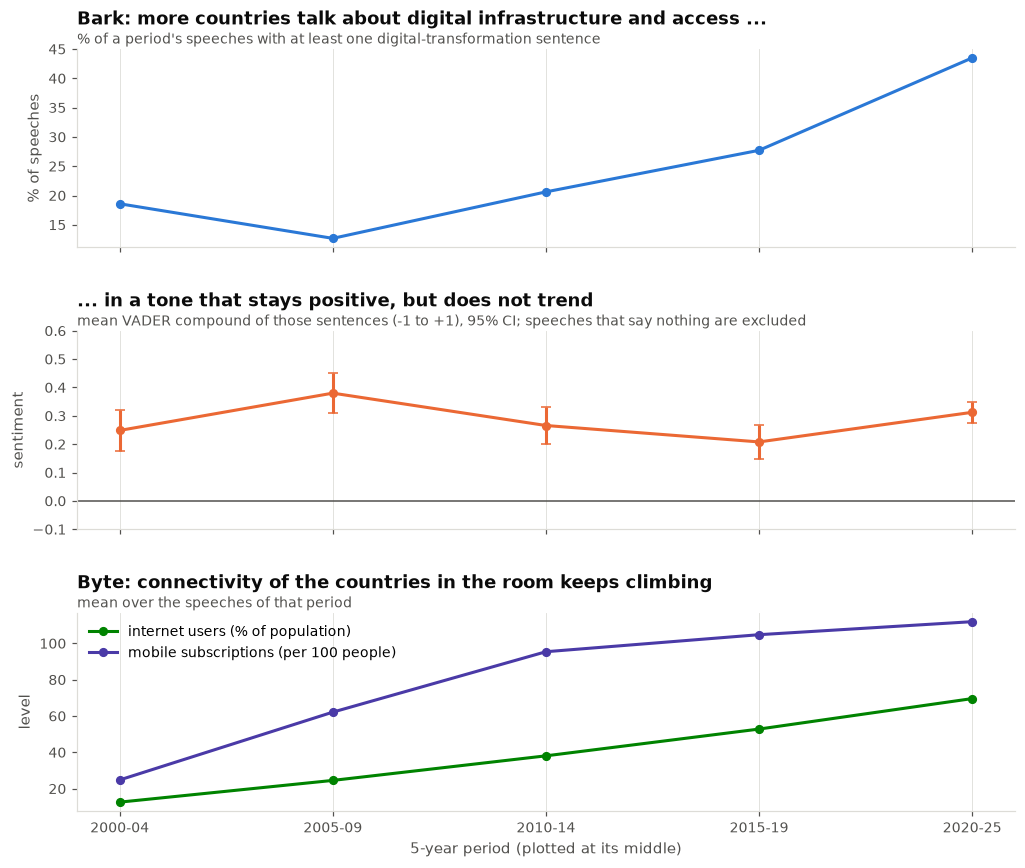

        mention_rate  sentiment  sent_sd  n_sent  internet  mobile    ci
period                                                                  
2000          18.590      0.250    0.480     174    12.600  24.830 0.070
2005          12.680      0.380    0.400     121    24.570  62.160 0.070
2010          20.620      0.270    0.460     199    38.100  95.410 0.060
2015          27.720      0.210    0.490     270    52.830 104.780 0.060
2020          43.500      0.310    0.430     502    69.610 111.950 0.040


In [7]:
# 2025 has no connectivity data yet, so it is folded into the last period (2020-25)
era = modern.assign(period=np.minimum((modern["year"] // 5) * 5, 2020))
by_period = era.groupby("period").agg(
    mention_rate=("mention", "mean"),
    sentiment=("sentiment", "mean"),
    sent_sd=("sentiment", "std"),
    n_sent=("sentiment", "count"),
    internet=("internet_users_pct", "mean"),
    mobile=("mobile_per_100", "mean"))
by_period["ci"] = 1.96 * by_period["sent_sd"] / np.sqrt(by_period["n_sent"])
x = by_period.index + 2  # plot each period at its middle

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True, gridspec_kw={"hspace": 0.42})

axes[0].plot(x, 100 * by_period["mention_rate"], color=BLUE, marker="o")
finish(axes[0], "Bark: more countries talk about digital infrastructure and access ...",
       "% of a period's speeches with at least one digital-transformation sentence",
       ylabel="% of speeches", legend=False)

axes[1].axhline(0, color=INK_SOFT, lw=1)
axes[1].errorbar(x, by_period["sentiment"], yerr=by_period["ci"], color=ORANGE, marker="o", capsize=3)
finish(axes[1], "... in a tone that stays positive, but does not trend",
       "mean VADER compound of those sentences (-1 to +1), 95% CI; speeches that say nothing are excluded",
       ylabel="sentiment", legend=False)
axes[1].set_ylim(-0.1, 0.6)

axes[2].plot(x, by_period["internet"], color=GREEN, marker="o", label="internet users (% of population)")
axes[2].plot(x, by_period["mobile"], color=VIOLET, marker="o", label="mobile subscriptions (per 100 people)")
finish(axes[2], "Byte: connectivity of the countries in the room keeps climbing",
       "mean over the speeches of that period", xlabel="5-year period (plotted at its middle)",
       ylabel="level")
axes[2].set_xticks(x, [f"{p}-{str(p + 4 + (p == 2020))[2:]}" for p in by_period.index])
plt.show()

print(by_period.assign(mention_rate=lambda f: 100 * f["mention_rate"]).round(2).to_string())


The volume of digital talk more than doubles (19% of speeches in 2000-04, 44% in 2020-25) while internet use in the countries in the room rises from about 13% to 70% of the population and mobile subscriptions from 25 to 112 per 100 people. **The tone, however, wanders between 0.21 and 0.38 with overlapping confidence intervals and no trend.** A shared upward trend in *volume* is a coincidence of timelines, not evidence that the two are linked, so the next check compares countries *within the same year*.

### 2.2 Across countries: no sorting by connectivity


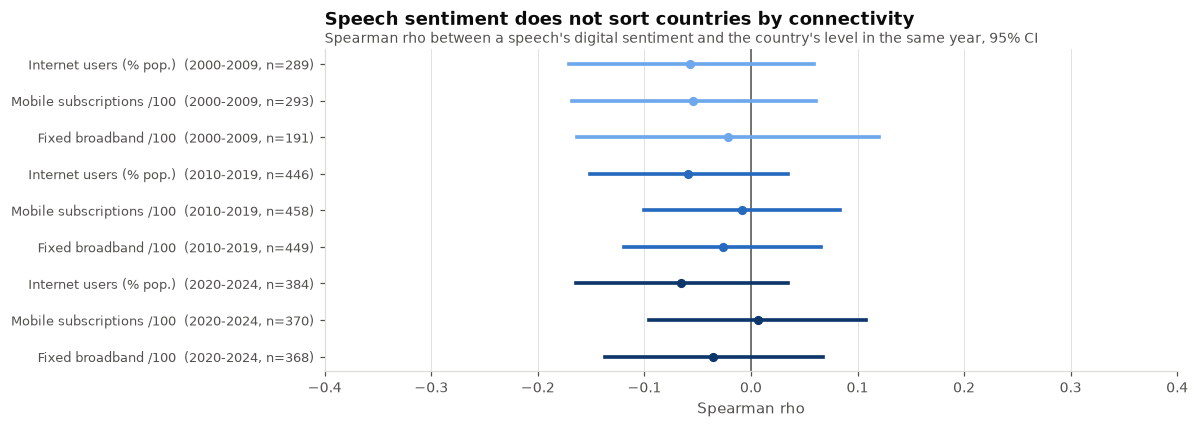

   window                   outcome   n    rho     p
2000-2009   Internet users (% pop.) 289 -0.057 0.336
2000-2009 Mobile subscriptions /100 293 -0.054 0.356
2000-2009      Fixed broadband /100 191 -0.022 0.765
2010-2019   Internet users (% pop.) 446 -0.059 0.216
2010-2019 Mobile subscriptions /100 458 -0.008 0.858
2010-2019      Fixed broadband /100 449 -0.027 0.574
2020-2024   Internet users (% pop.) 384 -0.065 0.202
2020-2024 Mobile subscriptions /100 370  0.006 0.902
2020-2024      Fixed broadband /100 368 -0.035 0.501


In [8]:
WINDOWS = [(2000, 2009), (2010, 2019), (2020, 2024)]
OUTCOMES = {"internet_users_pct": "Internet users (% pop.)",
            "mobile_per_100": "Mobile subscriptions /100",
            "broadband_per_100": "Fixed broadband /100"}

rows = []
for lo, hi in WINDOWS:
    sub = modern[(modern["year"].between(lo, hi)) & modern["sentiment"].notna()]
    for col, label in OUTCOMES.items():
        pair = sub[["sentiment", col]].dropna()
        r, p = stats.spearmanr(pair["sentiment"], pair[col])
        half = 1.96 / np.sqrt(len(pair) - 3)                      # Fisher-z interval
        z = np.arctanh(r)
        rows.append({"window": f"{lo}-{hi}", "outcome": label, "n": len(pair), "rho": r, "p": p,
                     "lo": np.tanh(z - half), "hi": np.tanh(z + half)})
cross = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(10, 3.8))
ypos = np.arange(len(cross))[::-1]
colors = {"2000-2009": SEQ_BLUE[2], "2010-2019": SEQ_BLUE[4], "2020-2024": SEQ_BLUE[6]}
ax.axvline(0, color=INK_SOFT, lw=1)
for y, r in zip(ypos, cross.itertuples()):
    ax.plot([r.lo, r.hi], [y, y], color=colors[r.window], lw=2.4)
    ax.plot(r.rho, y, "o", color=colors[r.window])
ax.set_yticks(ypos, [f"{r.outcome}  ({r.window}, n={r.n})" for r in cross.itertuples()], fontsize=8.5)
ax.set_xlim(-0.4, 0.4)
finish(ax, "Speech sentiment does not sort countries by connectivity",
       "Spearman rho between a speech's digital sentiment and the country's level in the same year, 95% CI",
       xlabel="Spearman rho", legend=False)
ax.xaxis.grid(True)
plt.show()
print(cross.drop(columns=["lo", "hi"]).to_string(index=False))


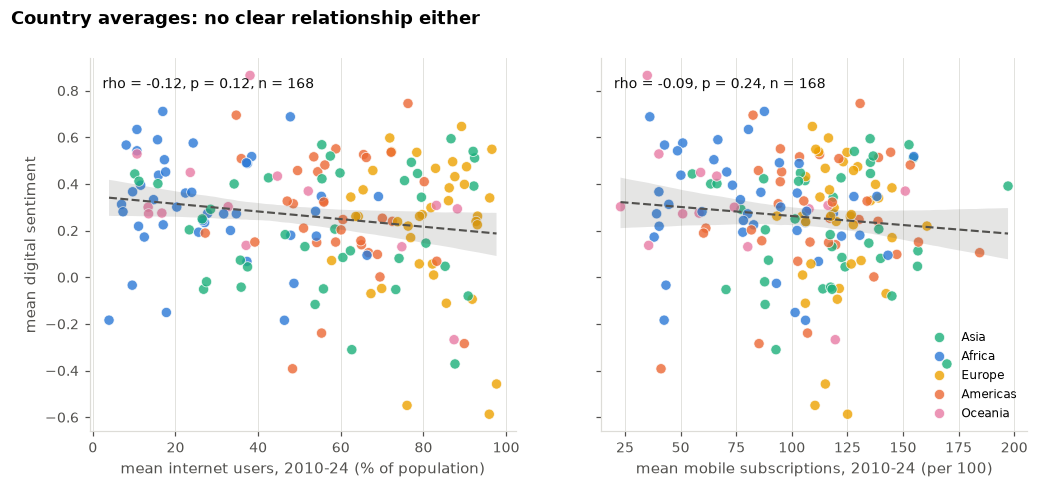

In [9]:
recent = modern[modern["year"].between(2010, 2024)]
country = (recent.groupby(["country_code", "region_name"])
           .agg(sentiment=("sentiment", "mean"), n_mentions=("sentiment", "count"),
                internet=("internet_users_pct", "mean"), mobile=("mobile_per_100", "mean"))
           .reset_index().query("n_mentions >= 2").dropna(subset=["internet"]))

fig, axes = plt.subplots(1, 2, figsize=(11, 4.4), sharey=True)
palette = dict(zip(sorted(country["region_name"].dropna().unique()), SERIES))
for ax, col, label in zip(axes, ["internet", "mobile"],
                          ["mean internet users, 2010-24 (% of population)",
                           "mean mobile subscriptions, 2010-24 (per 100)"]):
    sns.scatterplot(data=country, x=col, y="sentiment", hue="region_name", palette=palette,
                    s=45, alpha=0.8, ax=ax, legend=(col == "mobile"))
    sns.regplot(data=country, x=col, y="sentiment", scatter=False, color=INK_SOFT,
                line_kws={"lw": 1.4, "ls": "--"}, ci=95, ax=ax)
    r, p = stats.spearmanr(country[col], country["sentiment"])
    finish(ax, None, xlabel=label, ylabel="mean digital sentiment" if col == "internet" else "", legend=False)
    ax.text(0.03, 0.95, f"rho = {r:+.2f}, p = {p:.2f}, n = {len(country)}", transform=ax.transAxes,
            fontsize=9, color=INK, va="top")
axes[1].legend(loc="lower right", fontsize=8, title=None)
fig.suptitle("Country averages: no clear relationship either", x=0.06, ha="left", fontsize=12, fontweight="semibold")
plt.show()


Within-year correlations are all small (|rho| <= 0.07) and none is distinguishable from zero, for any decade or any of the three connectivity measures. Averaging each country over 2010-24 to reduce the single-sentence noise gives the same answer (rho = -0.12 for internet, -0.09 for mobile, both p > 0.1).

### 2.3 Who talks, and in what tone?

Splitting countries into connectivity terciles *within each year* separates the question of **whether** and **how much** a country talks from **how positive** it is.


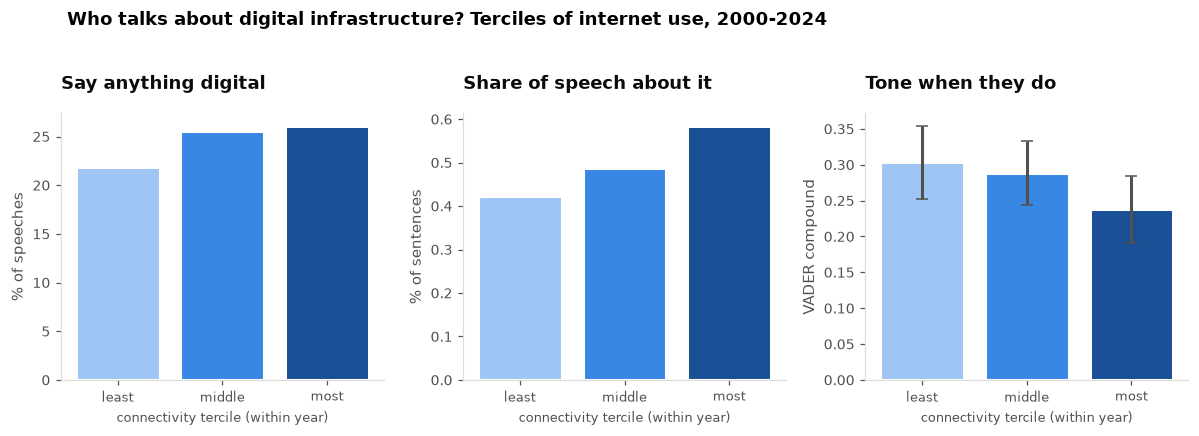

                 mention_rate  salience  sentiment    sd    n  promise_share    ci
connectivity                                                                      
least connected         0.219     0.004      0.303 0.469  331          0.277 0.051
middle                  0.255     0.005      0.288 0.447  389          0.192 0.044
most connected          0.261     0.006      0.238 0.474  399          0.224 0.046


In [10]:
conn = modern[modern["year"].between(2000, 2024) & modern["internet_users_pct"].notna()].copy()
conn["connectivity"] = conn.groupby("year")["internet_users_pct"].transform(
    lambda s: pd.cut(s.rank(method="first", pct=True), [0, 1 / 3, 2 / 3, 1],
                     labels=["least connected", "middle", "most connected"], include_lowest=True))

who = conn.groupby("connectivity", observed=True).agg(
    mention_rate=("mention", "mean"), salience=("salience", "mean"),
    sentiment=("sentiment", "mean"), sd=("sentiment", "std"), n=("sentiment", "count"),
    promise_share=("promise_share", "mean"))
who["ci"] = 1.96 * who["sd"] / np.sqrt(who["n"])

fig, axes = plt.subplots(1, 3, figsize=(11, 3.8))
shade = [SEQ_BLUE[1], SEQ_BLUE[3], SEQ_BLUE[5]]
for ax, (col, title, scale) in zip(axes, [("mention_rate", "Say anything digital", 100),
                                          ("salience", "Share of speech about it", 100),
                                          ("sentiment", "Tone when they do", 1)]):
    ax.bar(who.index, scale * who[col], color=shade, edgecolor="white", linewidth=2,
           yerr=(who["ci"] if col == "sentiment" else None), capsize=4, ecolor=INK_SOFT)
    finish(ax, title, ylabel={"mention_rate": "% of speeches", "salience": "% of sentences",
                              "sentiment": "VADER compound"}[col], legend=False)
    ax.xaxis.grid(False)
    ax.set_xticks(range(3), ["least", "middle", "most"], fontsize=8.5)
    ax.set_xlabel("connectivity tercile (within year)", fontsize=8.5)
fig.suptitle("Who talks about digital infrastructure? Terciles of internet use, 2000-2024",
             x=0.06, ha="left", fontsize=12, fontweight="semibold", y=1.03)
fig.tight_layout()
plt.show()
print(who.round(3).to_string())


Better-connected countries mention digital topics a little more often (22% to 26% of speeches) and devote more of the speech to them, but strike a slightly *cooler* tone (0.30 in the least-connected tercile vs 0.24 in the most). The tone gap is at the edge of what the confidence intervals can resolve.

### 2.4 Is the tone gradient about countries or about change?

The last exploratory check regresses the *level* of connectivity on a speech's sentiment, standardised so the coefficient reads "percentage points per +1 SD of sentiment". Adding **country fixed effects** removes everything that is stable about a country and asks only whether a country's *own* connectivity moves with its own tone.


In [11]:
sample = modern[modern["year"] <= 2024]
rows = []
for outcome, label in [("internet_users_pct", "internet users (pp)"), ("mobile_per_100", "mobile subs (per 100)")]:
    d = sample.assign(sentiment_z=zscore(sample["sentiment"]))
    for name, kw in [("pooled, year FE", dict()), ("country FE + year FE", dict(country_fe=True))]:
        f = fit(d, outcome, ["sentiment_z"], **kw)
        lo, hi = f.ci("sentiment_z")
        rows.append({"outcome": label, "specification": name, "n": f.n, "countries": f.n_countries,
                     "effect of +1 SD sentiment": f.coef["sentiment_z"], "95% CI": f"[{lo:+.2f}, {hi:+.2f}]",
                     "t": f.t["sentiment_z"]})
print("Level of connectivity regressed on a speech's digital sentiment (mention-only speeches, 2000-2024)")
print("Standard errors clustered by country.\n")
print(pd.DataFrame(rows).to_string(index=False))


Level of connectivity regressed on a speech's digital sentiment (mention-only speeches, 2000-2024)
Standard errors clustered by country.

              outcome        specification    n  countries  effect of +1 SD sentiment         95% CI      t
  internet users (pp)      pooled, year FE 1119        186                     -1.740 [-3.34, -0.14] -2.129
  internet users (pp) country FE + year FE 1119        186                      0.123 [-0.50, +0.75]  0.385
mobile subs (per 100)      pooled, year FE 1121        188                     -1.252 [-3.57, +1.06] -1.060
mobile subs (per 100) country FE + year FE 1121        188                     -0.014 [-1.16, +1.13] -0.024


### Q1 in short

* **Volume moves with connectivity; tone does not.** Digital talk becomes far more common as the world gets connected, but that is a shared time trend.
* **Across countries there is a weak negative gradient** (more connected, slightly less effusive): -1.7 pp of internet users per +1 SD of sentiment in the pooled model (95% CI -3.3 to -0.1).
* **That gradient is between countries, not within them.** With country fixed effects it collapses to +0.1 pp (CI -0.5 to +0.8), and the mobile-subscription models are null in both specifications. A country's tone does not rise as its own network grows.

So the exploratory answer to "all bark, no byte?" is that bark and byte are simply *unrelated* in tone. The lower-tone-when-connected pattern is a composition effect: countries that were already connected are cooler about the topic, and that does not change as they get more connected.


## 3. Q2 - Predictive: does sentiment forecast next year's gain, and does corruption matter?

### 3.1 Design

* **Target:** `gain_next`, the gain in the share of the population online from year `t` to `t+1`, in percentage points. It averages 2.65 pp/year (SD 3.3).
* **Predictor:** the sentiment (or framing) of the year-`t` speech.
* **Controls in every model:** the internet level at `t`, its square (adoption follows an S-curve, so gains shrink near saturation), log GDP per capita, and year fixed effects (the global rollout is a common trend).
* **Standard errors** are clustered by country. Predictive quality is judged **out of sample, holding out whole countries**.

The controls-only baseline is deliberately competitive: it already explains roughly 16-18% of next-year gains out of sample, so the speeches must add to *that*, not to nothing.


In [12]:
CONTROLS = ["internet_users_pct", "internet_sq", "log_gdp"]        # + year fixed effects in every model
q2 = panel[panel["year"].between(2000, 2023)].copy()
for col in ["sentiment", "net_tone", "promise_share", "salience", "sentiment_5y"]:
    q2[f"{col}_z"] = zscore(q2[col])

speaking = q2[q2["sentiment"].notna()]
usable = speaking.dropna(subset=["gain_next", *CONTROLS])
with_corr = usable.dropna(subset=["perceived_corruption"])
print(f"speeches 2000-2023:                                  {len(q2):,}")
print(f"  ... with a digital sentence:                       {len(speaking):,}")
print(f"  ... and a next-year gain + controls:               {len(usable):,}  ({usable['country_code'].nunique()} countries)")
print(f"  ... and Perceptions of Corruption (WHR):           {len(with_corr):,}  ({with_corr['country_code'].nunique()} countries)")
print()
print("target: next-year gain in internet users (percentage points)")
print(q2["gain_next"].describe().round(2).to_string())


speeches 2000-2023:                                  4,601
  ... with a digital sentence:                       1,072
  ... and a next-year gain + controls:               987  (179 countries)
  ... and Perceptions of Corruption (WHR):           574  (135 countries)

target: next-year gain in internet users (percentage points)
count   4,339.000
mean        2.650
std         3.340
min       -20.930
25%         0.550
50%         1.820
75%         3.720
max        40.440


### 3.2 Does any digital-speech measure predict the next-year gain?

Five different ways to read the same speeches, each standardised so a coefficient is "pp per +1 SD of the predictor".


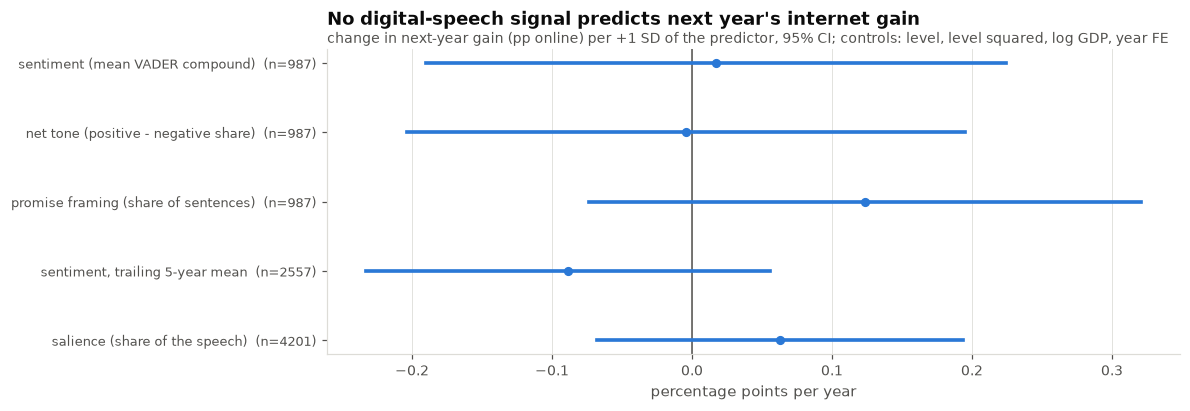

                           predictor                                        sample    n  countries  pp per +1 SD      t
     sentiment (mean VADER compound)              speeches with a digital sentence  987        179         0.017  0.162
net tone (positive - negative share)              speeches with a digital sentence  987        179        -0.004 -0.043
promise framing (share of sentences)              speeches with a digital sentence  987        179         0.123  1.227
     sentiment, trailing 5-year mean any speech with a mention in the last 5 years 2557        182        -0.089 -1.204
      salience (share of the speech)                                  all speeches 4201        186         0.063  0.938


In [13]:
SPECS = [
    ("sentiment (mean VADER compound)", "sentiment_z", "speeches with a digital sentence"),
    ("net tone (positive - negative share)", "net_tone_z", "speeches with a digital sentence"),
    ("promise framing (share of sentences)", "promise_share_z", "speeches with a digital sentence"),
    ("sentiment, trailing 5-year mean", "sentiment_5y_z", "any speech with a mention in the last 5 years"),
    ("salience (share of the speech)", "salience_z", "all speeches"),
]
rows = []
for label, col, who_ in SPECS:
    f = fit(q2, "gain_next", [col], CONTROLS)
    lo, hi = f.ci(col)
    rows.append({"predictor": label, "sample": who_, "n": f.n, "countries": f.n_countries,
                 "pp per +1 SD": f.coef[col], "lo": lo, "hi": hi, "t": f.t[col]})
forest = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(10, 3.6))
ypos = np.arange(len(forest))[::-1]
ax.axvline(0, color=INK_SOFT, lw=1)
for y, r in zip(ypos, forest.itertuples()):
    ax.plot([r.lo, r.hi], [y, y], color=BLUE, lw=2.4)
    ax.plot(r._5, y, "o", color=BLUE)
ax.set_yticks(ypos, [f"{r.predictor}  (n={r.n})" for r in forest.itertuples()], fontsize=8.5)
finish(ax, "No digital-speech signal predicts next year's internet gain",
       "change in next-year gain (pp online) per +1 SD of the predictor, 95% CI; "
       "controls: level, level squared, log GDP, year FE",
       xlabel="percentage points per year", legend=False)
ax.xaxis.grid(True)
plt.show()
print(forest.drop(columns=["lo", "hi"]).to_string(index=False))


None of the five is distinguishable from zero. The confidence intervals are informative: they exclude effects larger than about a third of a percentage point per SD, against an average gain of 2.65 pp a year. The largest point estimate is for promise framing (+0.12 pp per SD, CI -0.07 to +0.32).

### 3.3 Placebo and lag check: does talk follow byte, or lead it?

The same regression on the internet gain in the year *before* the speech and in the year *two years after* it. If sentiment reacted to recent progress, or led to progress with a delay, the first or last coefficient would move.


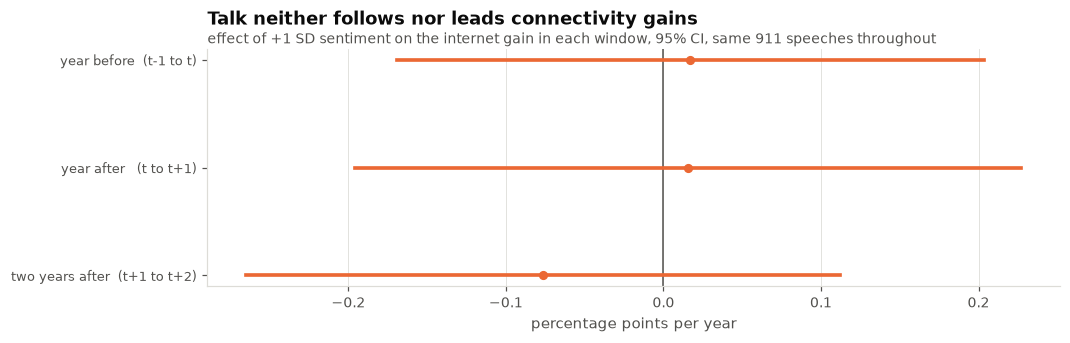

                       window   coef      t
      year before  (t-1 to t)  0.017  0.179
      year after   (t to t+1)  0.016  0.146
two years after  (t+1 to t+2) -0.076 -0.795


In [14]:
# Same regression, three different outcome windows around the speech.
ll = q2.dropna(subset=["sentiment", "gain_prev", "gain_next", "gain_next2", *CONTROLS])
rows = []
for col, label in [("gain_prev", "year before  (t-1 to t)"), ("gain_next", "year after   (t to t+1)"),
                   ("gain_next2", "two years after  (t+1 to t+2)")]:
    f = fit(ll, col, ["sentiment_z"], CONTROLS)
    lo, hi = f.ci("sentiment_z")
    rows.append({"window": label, "coef": f.coef["sentiment_z"], "lo": lo, "hi": hi, "t": f.t["sentiment_z"]})
ll_res = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(10, 2.8))
ypos = np.arange(len(ll_res))[::-1]
ax.axvline(0, color=INK_SOFT, lw=1)
for y, r in zip(ypos, ll_res.itertuples()):
    ax.plot([r.lo, r.hi], [y, y], color=ORANGE, lw=2.4)
    ax.plot(r.coef, y, "o", color=ORANGE)
ax.set_yticks(ypos, ll_res["window"], fontsize=8.5)
finish(ax, "Talk neither follows nor leads connectivity gains",
       f"effect of +1 SD sentiment on the internet gain in each window, 95% CI, same {len(ll):,} speeches throughout",
       xlabel="percentage points per year", legend=False)
ax.xaxis.grid(True)
plt.show()
print(ll_res.drop(columns=["lo", "hi"]).to_string(index=False))


Sentiment is no better a predictor of the year before (+0.02 pp per SD) than of the year after (+0.02 pp) or two years after (-0.08 pp). Talk neither reports past progress nor foreshadows future progress.

### 3.4 Out-of-sample prediction

Statistical significance is not the same as predictive value, so this section asks the question a forecaster would: do speech features improve predictions for **countries the model has never seen**? Whole countries are held out in repeated 5-fold splits. R2 is measured against always predicting the training-fold mean.

* **Sample A:** every speech with a digital sentence (n = 987).
* **Sample B:** those that also have a corruption score (n = 574), which is where the moderation question can be asked.
* A random forest is included in case the relationship is non-linear.


In [15]:
def year_dummies(df, years):
    return pd.get_dummies(pd.Categorical(df["year"], categories=years), drop_first=True).astype(float).to_numpy()


def cv_scores(df, target, models, repeats=20, folds=5, seed=0):
    """Out-of-sample R2 by *country-blocked* repeated K-fold.

    ``models`` maps a name to (list of numeric columns, estimator factory). Whole
    countries are held out, so a model cannot look up a country's own history. R2 is
    measured against always predicting the training-fold mean.
    """
    rng = np.random.default_rng(seed)
    years = sorted(df["year"].unique())
    countries = df["country_code"].unique()
    y = df[target].to_numpy()
    mats = {name: np.column_stack([df[cols].to_numpy(float), year_dummies(df, years)]) if cols is not None
            else np.zeros((len(df), 1)) for name, (cols, _) in models.items()}
    out = {name: [] for name in models}
    for _ in range(repeats):
        fold_of = dict(zip(rng.permutation(countries), np.arange(len(countries)) % folds))
        fold = df["country_code"].map(fold_of).to_numpy()
        pred = {name: np.empty(len(df)) for name in models}
        base = np.empty(len(df))
        for k in range(folds):
            tr, te = fold != k, fold == k
            base[te] = y[tr].mean()
            for name, (cols, make) in models.items():
                m = make().fit(mats[name][tr], y[tr])
                pred[name][te] = m.predict(mats[name][te])
        sse0 = ((y - base) ** 2).sum()
        for name in models:
            out[name].append(1 - ((y - pred[name]) ** 2).sum() / sse0)
    return pd.DataFrame(out)


def ols():
    return LinearRegression()


def forest_model():
    return RandomForestRegressor(n_estimators=200, min_samples_leaf=5, random_state=0, n_jobs=-1)


# Sample A: every speech with a digital sentence.  Sample B: those that also have a corruption score.
A = usable.copy()
B = with_corr.copy()
B["corr_c"] = B["perceived_corruption"] - B["perceived_corruption"].mean()
B["sent_c"] = B["sentiment"] - B["sentiment"].mean()
B["interaction"] = B["sent_c"] * B["corr_c"]

lin_A = {
    "controls only": (CONTROLS, ols),
    "+ sentiment": ([*CONTROLS, "sentiment"], ols),
    "+ sentiment + promise + salience": ([*CONTROLS, "sentiment", "promise_share", "salience"], ols),
}
lin_B = {
    "controls only": (CONTROLS, ols),
    "+ corruption": ([*CONTROLS, "corr_c"], ols),
    "+ corruption + sentiment": ([*CONTROLS, "corr_c", "sent_c"], ols),
    "+ corruption + sentiment + interaction": ([*CONTROLS, "corr_c", "sent_c", "interaction"], ols),
}
rf_B = {
    "forest: controls + corruption": ([*CONTROLS, "corr_c"], forest_model),
    "forest: + sentiment, promise, salience": ([*CONTROLS, "corr_c", "sentiment", "promise_share", "salience"], forest_model),
}

cvA = cv_scores(A, "gain_next", lin_A)
cvB = cv_scores(B, "gain_next", lin_B)
cvF = cv_scores(B, "gain_next", rf_B, repeats=8)

summary = pd.concat([
    cvA.agg(["mean", "std"]).T.assign(sample=f"A: n={len(A)}"),
    cvB.agg(["mean", "std"]).T.assign(sample=f"B: n={len(B)}"),
    cvF.agg(["mean", "std"]).T.assign(sample=f"B: n={len(B)}"),
])[["sample", "mean", "std"]].rename(columns={"mean": "out-of-sample R2", "std": "sd over repeats"})
print("country-blocked cross-validation, target = next-year internet gain (pp)\n")
print(summary.to_string())


country-blocked cross-validation, target = next-year internet gain (pp)

                                          sample  out-of-sample R2  sd over repeats
controls only                           A: n=987             0.183            0.008
+ sentiment                             A: n=987             0.181            0.008
+ sentiment + promise + salience        A: n=987             0.177            0.009
controls only                           B: n=574             0.162            0.009
+ corruption                            B: n=574             0.161            0.010
+ corruption + sentiment                B: n=574             0.157            0.010
+ corruption + sentiment + interaction  B: n=574             0.159            0.011
forest: controls + corruption           B: n=574             0.133            0.026
forest: + sentiment, promise, salience  B: n=574             0.149            0.015


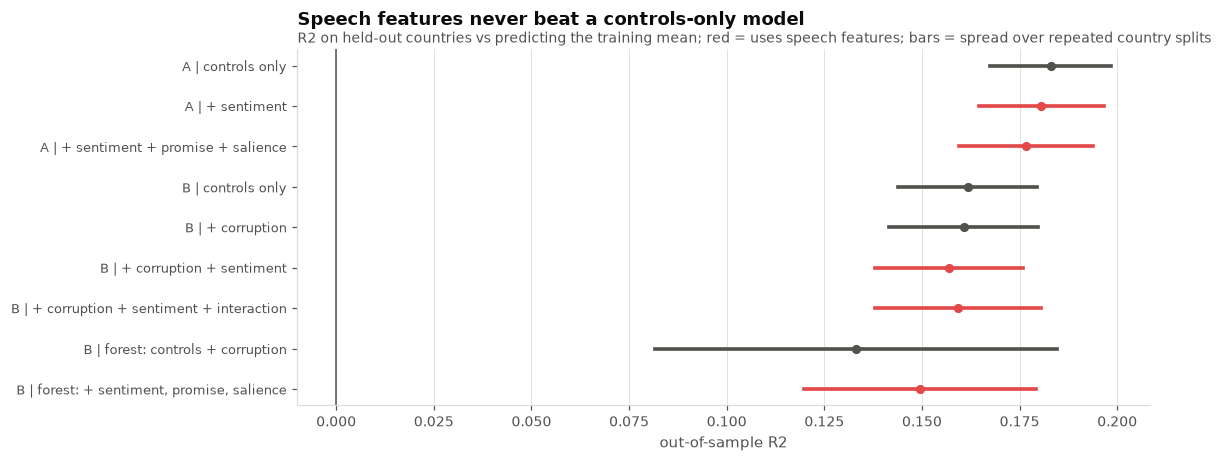

In [16]:
allcv = pd.concat([cvA.add_prefix("A | "), cvB.add_prefix("B | "), cvF.add_prefix("B | ")], axis=1)
mean, sd = allcv.mean(), allcv.std()
order = list(mean.index)
fig, ax = plt.subplots(figsize=(10, 4.2))
ypos = np.arange(len(order))[::-1]
ax.axvline(0, color=INK_SOFT, lw=1)
for y, name in zip(ypos, order):
    c = RED if "sentiment" in name else INK_SOFT
    ax.plot([mean[name] - 1.96 * sd[name], mean[name] + 1.96 * sd[name]], [y, y], color=c, lw=2.4)
    ax.plot(mean[name], y, "o", color=c)
ax.set_yticks(ypos, order, fontsize=8.5)
finish(ax, "Speech features never beat a controls-only model",
       "R2 on held-out countries vs predicting the training mean; red = uses speech features; bars = spread over repeated country splits",
       xlabel="out-of-sample R2", legend=False)
ax.xaxis.grid(True)
plt.show()


Adding sentiment never improves on the controls-only model in either sample (Sample A: 0.183 vs 0.181; Sample B: 0.162 vs 0.157). Perceived corruption on its own adds nothing out of sample either (0.161). The forest with speech features scores higher than the forest without them (0.149 vs 0.133) but still lower than the plain linear controls-only model (0.162), so that gain is recovering ground, not adding signal.

**So, to the question "to what extent can sentiment predict next year's gain?", the answer is: not at all, for countries the model has not seen.**

### 3.5 Does perceived corruption moderate the relationship?

`sentiment x corruption` is added to the model. Both variables are centred, so the sentiment coefficient is the effect at *average* corruption and the interaction says how that effect changes as corruption rises.


Moderation model: gain_next ~ sentiment x corruption + controls + year FE   (n=574, 135 countries, R2=0.238)

                     coef    se      t
sent_c             -0.326 0.336 -0.972
corr_c              0.510 0.687  0.742
interaction        -2.545 1.106 -2.301
internet_users_pct  0.104 0.024  4.304
internet_sq        -0.174 0.019 -9.340
log_gdp             1.436 0.370  3.882

sentiment and corruption are centred, so 'sent_c' is the effect of +1.0 sentiment at average corruption (sd of sentiment = 0.46, sd of corruption = 0.18).


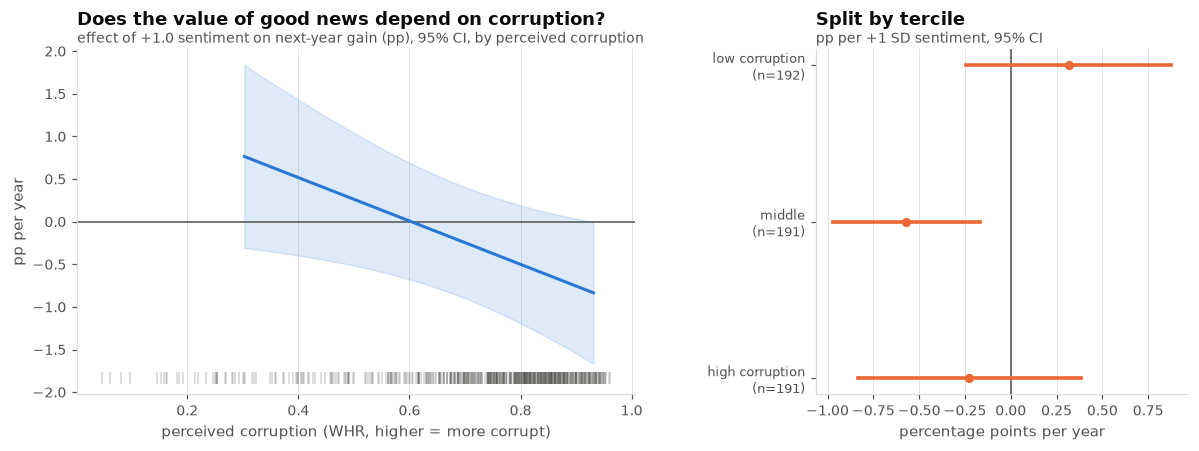

        tercile   n  mean corruption  mean internet %  pp per +1 SD      t
 low corruption 192            0.524           68.399         0.315  1.105
         middle 191            0.783           49.212        -0.570 -2.780
high corruption 191            0.888           50.994        -0.226 -0.728


In [17]:
mod = fit(B, "gain_next", ["sent_c", "corr_c", "interaction"], CONTROLS)
print(f"Moderation model: gain_next ~ sentiment x corruption + controls + year FE   "
      f"(n={mod.n}, {mod.n_countries} countries, R2={mod.r2:.3f})\n")
tab = pd.DataFrame({"coef": mod.coef, "se": mod.se, "t": mod.t})
print(tab.round(3).to_string())
print(f"\nsentiment and corruption are centred, so 'sent_c' is the effect of +1.0 sentiment at average corruption "
      f"(sd of sentiment = {B['sentiment'].std():.2f}, sd of corruption = {B['perceived_corruption'].std():.2f}).")

# marginal effect of sentiment across the corruption range
grid = np.linspace(B["perceived_corruption"].quantile(0.05), B["perceived_corruption"].quantile(0.95), 60)
gc = grid - B["perceived_corruption"].mean()
slope = mod.coef["sent_c"] + mod.coef["interaction"] * gc
var = mod.cov.loc["sent_c", "sent_c"] + gc**2 * mod.cov.loc["interaction", "interaction"] + 2 * gc * mod.cov.loc["sent_c", "interaction"]
band = 1.96 * np.sqrt(var)

# the same slope estimated separately in corruption terciles (no interaction imposed)
B["corr_tercile"] = pd.qcut(B["perceived_corruption"], 3, labels=["low corruption", "middle", "high corruption"])
terc = []
for name, g in B.groupby("corr_tercile", observed=True):
    f = fit(g.assign(sentiment_z=zscore(g["sentiment"])), "gain_next", ["sentiment_z"], CONTROLS)
    lo, hi = f.ci("sentiment_z")
    terc.append({"tercile": name, "n": f.n, "mean corruption": g["perceived_corruption"].mean(),
                 "mean internet %": g["internet_users_pct"].mean(), "pp per +1 SD": f.coef["sentiment_z"],
                 "lo": lo, "hi": hi, "t": f.t["sentiment_z"]})
terc = pd.DataFrame(terc)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), gridspec_kw={"width_ratios": [1.5, 1]})
ax = axes[0]
ax.axhline(0, color=INK_SOFT, lw=1)
ax.fill_between(grid, slope - band, slope + band, color=BLUE, alpha=0.15)
ax.plot(grid, slope, color=BLUE)
ax.plot(B["perceived_corruption"], np.full(len(B), ax.get_ylim()[0]), "|", color=INK_SOFT, alpha=0.25, ms=8)
finish(ax, "Does the value of good news depend on corruption?",
       "effect of +1.0 sentiment on next-year gain (pp), 95% CI, by perceived corruption",
       xlabel="perceived corruption (WHR, higher = more corrupt)", ylabel="pp per year", legend=False)
ax = axes[1]
ypos = np.arange(len(terc))[::-1]
ax.axvline(0, color=INK_SOFT, lw=1)
for y, r in zip(ypos, terc.itertuples()):
    ax.plot([r.lo, r.hi], [y, y], color=ORANGE, lw=2.4)
    ax.plot(r._5, y, "o", color=ORANGE)
ax.set_yticks(ypos, [f"{r.tercile}\n(n={r.n})" for r in terc.itertuples()], fontsize=8.5)
finish(ax, "Split by tercile", "pp per +1 SD sentiment, 95% CI", xlabel="percentage points per year", legend=False)
ax.xaxis.grid(True)
fig.tight_layout()
plt.show()
print(terc.drop(columns=["lo", "hi"]).to_string(index=False))


The interaction is negative (-2.5, t = -2.3): at *low* perceived corruption, warmer digital talk goes with slightly *larger* next-year gains; at *high* corruption, with slightly *smaller* ones. That is the "bark without byte" pattern the question anticipated, but the evidence is thin:

* the slope's confidence band excludes zero only at the far high-corruption end;
* the tercile split is not monotonic: the effect is significant only in the *middle* tercile (-0.57 pp per SD, t = -2.8), and the low- and high-corruption terciles are indistinguishable from zero;
* most countries sit at high perceived corruption (tercile means 0.52 / 0.78 / 0.89), so the low-corruption end of the line rests on relatively few speeches.

### 3.6 How robust is the interaction?

The baseline, six variations of it, a placebo outcome, and a permutation test that shuffles sentiment among speeches from the *same year*. The moderator was part of the question, but we still weigh the p-values against the number of comparisons made in this section.


In [18]:
def interaction_row(label, df, y="gain_next", **kw):
    f = fit(df, y, ["sent_c", "corr_c", "interaction"], kw.pop("controls", CONTROLS), **kw)
    lo, hi = f.ci("interaction")
    return {"specification": label, "n": f.n, "sentiment main effect": f.coef["sent_c"],
            "interaction": f.coef["interaction"], "95% CI": f"[{lo:+.2f}, {hi:+.2f}]", "t": f.t["interaction"]}


lo_q, hi_q = B["gain_next"].quantile([0.02, 0.98])
B_log = B.assign(log_gain=np.log1p(B["internet_users_pct"] + B["gain_next"]) - np.log1p(B["internet_users_pct"]))
B_cm = B.merge(panel.groupby("country_code")["perceived_corruption"].mean().rename("corr_country_mean"),
               on="country_code")
B_cm["corr_c"] = B_cm["corr_country_mean"] - B_cm["corr_country_mean"].mean()
B_cm["interaction"] = B_cm["sent_c"] * B_cm["corr_c"]

robust = pd.DataFrame([
    interaction_row("baseline", B),
    interaction_row("gain winsorised at 2% / 98%", B.assign(gain_next=B["gain_next"].clip(lo_q, hi_q))),
    interaction_row("relative gain (log points)", B_log, y="log_gain"),
    interaction_row("only countries below 60% online", B[B["internet_users_pct"] < 60]),
    interaction_row("country-average corruption (less noisy)", B_cm),
    interaction_row("country fixed effects", B, country_fe=True),
    interaction_row("no controls beyond year FE", B, controls=[]),
    interaction_row("placebo: gain in the year before", B, y="gain_prev"),
])
print(robust.to_string(index=False))

# Permutation test: shuffle sentiment among speeches of the same year and re-estimate the interaction.
def permutation_p(df, n_perm=2000, seed=1):
    rng = np.random.default_rng(seed)
    X = _design(df, ["sent_c", "corr_c", "interaction"], CONTROLS, True, False)
    y = df["gain_next"].to_numpy()
    cols = list(X.columns)
    i_s, i_int = cols.index("sent_c"), cols.index("interaction")
    Xv = X.to_numpy().copy()
    by_year = [np.flatnonzero(df["year"].to_numpy() == yr) for yr in df["year"].unique()]
    corr = df["corr_c"].to_numpy()
    obs = np.linalg.lstsq(Xv, y, rcond=None)[0][i_int]
    draws = np.empty(n_perm)
    for b in range(n_perm):
        s = Xv[:, i_s].copy()
        for idx in by_year:
            s[idx] = rng.permutation(s[idx])
        Xp = Xv.copy()
        Xp[:, i_s], Xp[:, i_int] = s, s * corr
        draws[b] = np.linalg.lstsq(Xp, y, rcond=None)[0][i_int]
    return obs, (np.abs(draws) >= abs(obs)).mean(), draws


obs, p_perm, draws = permutation_p(B)
print(f"\npermutation test of the interaction: observed {obs:+.2f}, two-sided p = {p_perm:.3f} "
      f"(2,000 within-year shuffles of sentiment)")


                          specification   n  sentiment main effect  interaction          95% CI      t
                               baseline 574                 -0.326       -2.545  [-4.71, -0.38] -2.301
            gain winsorised at 2% / 98% 574                 -0.233       -1.557  [-3.07, -0.04] -2.013
             relative gain (log points) 574                 -0.009       -0.040  [-0.10, +0.02] -1.328
        only countries below 60% online 266                 -0.576       -4.424 [-13.10, +4.25] -1.000
country-average corruption (less noisy) 574                 -0.323       -2.638  [-4.80, -0.48] -2.390
                  country fixed effects 574                 -0.236       -2.078  [-4.89, +0.73] -1.450
             no controls beyond year FE 574                 -0.424       -2.261  [-4.78, +0.26] -1.758
       placebo: gain in the year before 574                 -0.147        0.455  [-1.63, +2.54]  0.427



permutation test of the interaction: observed -2.54, two-sided p = 0.052 (2,000 within-year shuffles of sentiment)


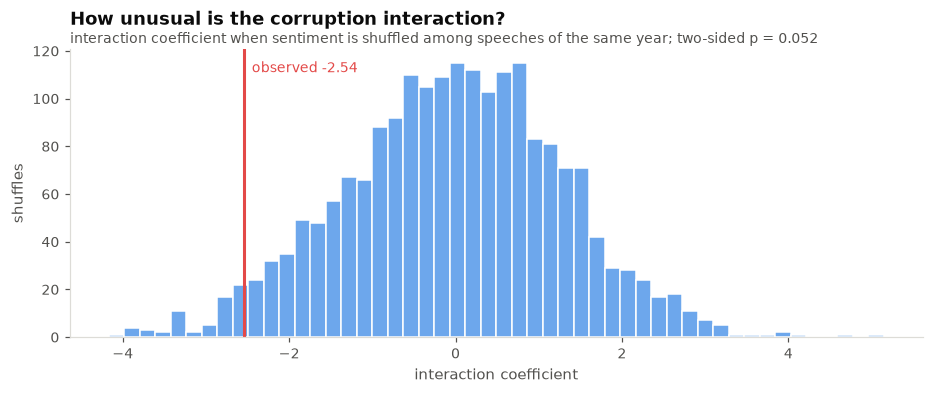

In [19]:
fig, ax = plt.subplots(figsize=(10, 3.4))
ax.hist(draws, bins=50, color=SEQ_BLUE[2], edgecolor="white")
ax.axvline(obs, color=RED, lw=2)
ax.text(obs, ax.get_ylim()[1] * 0.92, f"  observed {obs:+.2f}", color=RED, ha="left", fontsize=9)
finish(ax, "How unusual is the corruption interaction?",
       f"interaction coefficient when sentiment is shuffled among speeches of the same year; two-sided p = {p_perm:.3f}",
       xlabel="interaction coefficient", ylabel="shuffles", legend=False)
ax.xaxis.grid(False)
plt.show()


The interaction is significant in the baseline (t = -2.3), with winsorised gains (-2.0) and with country-average corruption (-2.4), but not with relative (log) gains (-1.3), country fixed effects (-1.4), no controls (-1.8) or countries below 60% online (-1.0). The placebo on the *previous* year's gain has the opposite sign and is nowhere near significant, which is what we would want to see. The permutation p-value of **0.052** says that shuffling sentiment among same-year speeches produces an interaction this large about 1 time in 20. Suggestive, not established.

### 3.7 Does a stricter vocabulary change anything?

The digital lexicons include a few terms that can fire outside a digital context: *universal access* (often health care), *grid* (power), *web* (a "web" of alliances) and *satellite* (Cold War "satellite states"). They account for roughly one in ten vocabulary hits since 2000. The last check removes them and re-runs the headline results.


In [20]:
# Strict vocabulary: drop the terms most likely to fire outside a digital context
# ("universal access" to health care, a power "grid", a "web" of alliances, "satellite" states).
AMBIGUOUS = frozenset({"universal_access", "grid", "web", "satellite"})
_, known = lexicon_matcher()
assert AMBIGUOUS <= set(known), AMBIGUOUS - set(known)

strict = digital_scores(drop=AMBIGUOUS)
strict = strict.assign(sentiment_strict=strict["dig_sum"] / strict["dig_n"])[["country_code", "year", "sentiment_strict"]]
q2s = q2.merge(strict, on=["country_code", "year"], how="left")
q2s["sentiment_strict_z"] = zscore(q2s["sentiment_strict"])

print(f"speeches with a digital sentence: {q2s['sentiment'].notna().sum():,} (full vocabulary) -> "
      f"{q2s['sentiment_strict'].notna().sum():,} (strict)\n")

rows = []
for label, col in [("full vocabulary", "sentiment"), ("strict vocabulary", "sentiment_strict")]:
    pair = modern.merge(strict, on=["country_code", "year"], how="left") if col == "sentiment_strict" else modern
    pair = pair[pair["year"] <= 2024][[col, "internet_users_pct"]].dropna()
    rho, p = stats.spearmanr(pair[col], pair["internet_users_pct"])
    f = fit(q2s.assign(z=zscore(q2s[col])), "gain_next", ["z"], CONTROLS)
    Bs = q2s.dropna(subset=[col, "perceived_corruption", "gain_next", *CONTROLS]).copy()
    Bs["sent_c"] = Bs[col] - Bs[col].mean()
    Bs["corr_c"] = Bs["perceived_corruption"] - Bs["perceived_corruption"].mean()
    Bs["interaction"] = Bs["sent_c"] * Bs["corr_c"]
    m = fit(Bs, "gain_next", ["sent_c", "corr_c", "interaction"], CONTROLS)
    rows.append({"vocabulary": label,
                 "Q1: rho with internet users": rho, "Q1: p": p,
                 "Q2: pp per +1 SD": f.coef["z"], "Q2: t": f.t["z"],
                 "Q2: interaction": m.coef["interaction"], "interaction t": m.t["interaction"], "n (moderation)": m.n})
print(pd.DataFrame(rows).to_string(index=False))


speeches with a digital sentence: 1,072 (full vocabulary) -> 914 (strict)

       vocabulary  Q1: rho with internet users  Q1: p  Q2: pp per +1 SD  Q2: t  Q2: interaction  interaction t  n (moderation)
  full vocabulary                       -0.050  0.092             0.017  0.162           -2.545         -2.301             574
strict vocabulary                       -0.039  0.221             0.092  0.802           -2.712         -2.487             496


### Q2 in short

* **Prediction: no.** Sentiment, net tone, promise framing, salience and trailing sentiment all have confidence intervals centred on zero; none improves out-of-sample prediction of next year's internet gain for unseen countries, linear or non-linear. A stricter vocabulary changes nothing.
* **Timing: neither leads nor follows.** The coefficient is the same size (about zero) for the year before and the year after.
* **Corruption as a moderator: a hint, not a finding.** The interaction has the direction the "trust" framing suggests (upbeat talk is associated with *smaller* gains where perceived corruption is high), but it is fragile across specifications, non-monotonic across terciles, borderline under a permutation test (p = 0.052), and it adds nothing to out-of-sample prediction.


## 4. Conclusions and limitations

### The answer to "All bark and no byte?"

**In this corpus, the bark and the byte live in separate worlds.** Countries talk far more about digital infrastructure than they used to (19% to 44% of speeches) while connectivity rose everywhere, but *how positively* a country speaks tells us essentially nothing about *how much connectivity it has* (Q1) or *how quickly it will gain more* (Q2). Optimism is not a leading indicator of delivery, and pessimism is not a warning sign. The only whisper of the "restoring trust" story is that the warm-talk-but-slower-gains pattern shows up among countries perceived as more corrupt, and we would not put weight on it without replication.

### What this analysis cannot say

* **Measurement noise probably biases towards zero.** The typical digital speech is one sentence long and VADER is a general-purpose sentiment model: "cyber threats" is scored negative and "connectivity" scored neutral regardless of whether the country is delivering. Classical measurement error shrinks coefficients toward zero, so "no relationship" partly reflects a blunt instrument. The confidence intervals are the honest summary: they rule out anything but small effects, they do not prove there is none.
* **Selection.** Sentiment exists only when a country chose to speak about digital topics, and that choice is itself correlated with connectivity. Analyses on all speeches (salience, the mention flag, trailing means) point the same way.
* **A speech is not a policy.** One official speaks for the whole government once a year; the internet gain reflects years of investment, private telecom markets and foreign firms. The direction of causality is not identified and we do not claim it.
* **Outcome data are imperfect.** The World Bank internet-user series is survey-based or modelled for many countries and is revised, and 2025 has no data yet, which caps the predictive sample at speeches through 2023.
* **Corruption is a perception** measured by a survey of citizens (WHR), from 2005 only, and concentrated at the high end.
* **Multiple comparisons.** The Q2 section reports around fifteen specifications; one borderline result among them is what chance alone would give.
* **Vocabulary.** The lexicons are hand-built. The strict-vocabulary check removes the most ambiguous terms, but terms such as *connectivity* and *online* still fire on non-infrastructure sentences (regional or transport "connectivity", online meetings during COVID-19).
